# Notebook 6: Train, tune, evaluate

In [1]:
import sys
assert "olist_mlops" in sys.executable, f"wrong kernel selected in the editor - expected the olist_mlops env, got: {sys.executable}"

In [2]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import ParameterSampler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
)
from sklearn.inspection import permutation_importance

## read the feature tables from notebook 5

In [3]:
ARTIFACTS_DIR = Path("artifacts")
CHARTS_DIR = Path("charts")
CHARTS_DIR.mkdir(exist_ok=True)

train = pd.read_csv(ARTIFACTS_DIR / "05_train_features.csv")
val = pd.read_csv(ARTIFACTS_DIR / "05_val_features.csv")
test = pd.read_csv(ARTIFACTS_DIR / "05_test_features.csv")

feature_list = json.load(open(ARTIFACTS_DIR / "05_feature_list.json"))

X_train, y_train = train[feature_list], train["late"]
X_val, y_val = val[feature_list], val["late"]
X_test, y_test = test[feature_list], test["late"]

X_train.shape, X_val.shape, X_test.shape

((67533, 74), (14471, 74), (14472, 74))

## a helper to score any fitted model on a split

accuracy alone would look great here just by predicting "on time" for everything (91% of
orders), so we track precision/recall/f1 for the late class plus roc-auc and pr-auc
(average precision), which is the one that matters most for a rare positive class.

In [4]:
def evaluate(model, X, y, threshold=0.5):
    proba = model.predict_proba(X)[:, 1]
    preds = (proba >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y, preds),
        "precision": precision_score(y, preds, zero_division=0),
        "recall": recall_score(y, preds, zero_division=0),
        "f1": f1_score(y, preds, zero_division=0),
        "roc_auc": roc_auc_score(y, proba),
        "pr_auc": average_precision_score(y, proba),
    }

## 1. baseline - always predict the majority class (on time)

In [5]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

evaluate(baseline, X_val, y_val)

{'accuracy': 0.9465828208140419,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'roc_auc': 0.5,
 'pr_auc': 0.053417179185958126}

this is the floor: high accuracy (just from never predicting "late"), but 0 recall - it
never catches a single late order. anything we build has to beat this on recall/pr-auc,
not on accuracy.

## 2. a model that does not handle the imbalance

In [6]:
plain_model = HistGradientBoostingClassifier(random_state=42)
plain_model.fit(X_train, y_train)

evaluate(plain_model, X_val, y_val)

{'accuracy': 0.9463064059152788,
 'precision': 0.16666666666666666,
 'recall': 0.00129366106080207,
 'f1': 0.0025673940949935813,
 'roc_auc': 0.7059980994572063,
 'pr_auc': 0.11795913968814846}

no class_weight, default settings. expect recall to still be poor - the model has no reason
to care about the minority class, it can get a low loss by mostly predicting "on time" too.

## 3. final model - broader search across model families, tuned on validation

trying logistic regression, random forest, extra trees, and histogram gradient boosting,
each with class_weight="balanced" and a random sample of hyperparameters (a fixed val
split, not cv folds, so ParameterSampler + a manual loop scored on val - not GridSearchCV,
which would re-fold train internally).

In [7]:
model_classes = {
    "logistic_regression": LogisticRegression,
    "random_forest": RandomForestClassifier,
    "extra_trees": ExtraTreesClassifier,
    "hist_gradient_boosting": HistGradientBoostingClassifier,
}

search_space = {
    "logistic_regression": ({"C": [0.001, 0.01, 0.1, 1, 10, 100], "max_iter": [1000]}, 6),
    "random_forest": ({
        "n_estimators": [200, 300, 400, 500],
        "max_depth": [None, 6, 10, 15, 20],
        "min_samples_leaf": [1, 2, 5, 10, 20],
        "max_features": ["sqrt", "log2", 0.5],
    }, 10),
    "extra_trees": ({
        "n_estimators": [200, 300, 400, 500],
        "max_depth": [None, 6, 10, 15, 20],
        "min_samples_leaf": [1, 2, 5, 10, 20],
        "max_features": ["sqrt", "log2", 0.5],
    }, 10),
    "hist_gradient_boosting": ({
        "max_depth": [3, 5, 7, 10, None],
        "learning_rate": [0.02, 0.05, 0.1, 0.15],
        "max_iter": [100, 150, 200, 300],
        "l2_regularization": [0, 0.5, 1, 2, 5],
        "min_samples_leaf": [10, 20, 30, 50],
    }, 15),
}

search_results = []
for model_name, (param_dist, n_iter) in search_space.items():
    sampler = ParameterSampler(param_dist, n_iter=n_iter, random_state=42)
    for params in sampler:
        model = model_classes[model_name](class_weight="balanced", random_state=42, **params)
        model.fit(X_train, y_train)
        search_results.append({"model_type": model_name, "params": params, **evaluate(model, X_val, y_val)})
        print(model_name, params, "-> pr_auc:", round(search_results[-1]["pr_auc"], 4))

search_df = pd.DataFrame(search_results).sort_values("pr_auc", ascending=False)
search_df[["model_type", "params", "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]].head(10)

logistic_regression {'max_iter': 1000, 'C': 0.001} -> pr_auc: 0.1601


logistic_regression {'max_iter': 1000, 'C': 0.01} -> pr_auc: 0.1618


logistic_regression {'max_iter': 1000, 'C': 0.1} -> pr_auc: 0.1661


logistic_regression {'max_iter': 1000, 'C': 1} -> pr_auc: 0.1667


logistic_regression {'max_iter': 1000, 'C': 10} -> pr_auc: 0.1668


...

hist_gradient_boosting {'min_samples_leaf': 30, 'max_iter': 200, 'max_depth': 7, 'learning_rate': 0.1, 'l2_regularization': 5} -> pr_auc: 0.1319


hist_gradient_boosting {'min_samples_leaf': 50, 'max_iter': 150, 'max_depth': 3, 'learning_rate': 0.05, 'l2_regularization': 0} -> pr_auc: 0.1368


hist_gradient_boosting {'min_samples_leaf': 10, 'max_iter': 150, 'max_depth': 7, 'learning_rate': 0.05, 'l2_regularization': 5} -> pr_auc: 0.1341


hist_gradient_boosting {'min_samples_leaf': 50, 'max_iter': 100, 'max_depth': 3, 'learning_rate': 0.1, 'l2_regularization': 2} -> pr_auc: 0.1387


,model_type,params,accuracy,precision,recall,f1,roc_auc,pr_auc
4,logistic_regression,"{'max_iter': 1000, 'C': 10}",0.689310,0.114197,0.712807,0.196856,0.773962,0.166771
3,logistic_regression,"{'max_iter': 1000, 'C': 1}",0.689171,0.113990,0.711514,0.196499,0.773905,0.166679
2,logistic_regression,"{'max_iter': 1000, 'C': 0.1}",0.688895,0.114055,0.712807,0.196645,0.775156,0.166124
5,logistic_regression,"{'max_iter': 1000, 'C': 100}",0.690139,0.114482,0.712807,0.197279,0.773349,0.166119
1,logistic_regression,"{'max_iter': 1000, 'C': 0.01}",0.690346,0.115512,0.720569,0.199106,0.774299,0.161763
0,logistic_regression,"{'max_iter': 1000, 'C': 0.001}",0.691037,0.116549,0.727038,0.200894,0.771136,0.160092
12,random_forest,"{'n_estimators': 200, 'min_samples_leaf': 20, ...",0.904913,0.188854,0.236740,0.210103,0.741450,0.150759
9,random_forest,"{'n_estimators': 300, 'min_samples_leaf': 5, '...",0.941193,0.280899,0.064683,0.105152,0.744579,0.150540
13,random_forest,"{'n_estimators': 300, 'min_samples_leaf': 5, '...",0.924746,0.212727,0.151358,0.176871,0.727105,0.147178
14,random_forest,"{'n_estimators': 300, 'min_samples_leaf': 2, '...",0.946168,0.350000,0.009056,0.017654,0.738728,0.146751


In [8]:
# search_df is already sorted by validation pr-auc, so the top row is the pick.
# selection uses validation only - the test set has no say in which model ships.
best_row = search_df.iloc[0]
best_model_type = best_row["model_type"]
best_params = best_row["params"]

best_model = model_classes[best_model_type](class_weight="balanced", random_state=42, **best_params)
best_model.fit(X_train, y_train)

print("best model type:", best_model_type)
print("best params:", best_params)
evaluate(best_model, X_val, y_val)

best model type: logistic_regression
best params: {'max_iter': 1000, 'C': 10}


{'accuracy': 0.6893096537903393,
 'precision': 0.11419689119170985,
 'recall': 0.7128072445019404,
 'f1': 0.19685602000714542,
 'roc_auc': 0.7739615815341735,
 'pr_auc': 0.16677097276662847}

## tune the decision threshold on validation

0.5 is arbitrary - scan thresholds and pick the one that gives the best f1 on the late
class, using validation only.

In [9]:
proba_val = best_model.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y_val, (proba_val >= t).astype(int)) for t in thresholds]
best_threshold = round(float(thresholds[np.argmax(f1_scores)]), 2)

print("best threshold (max f1 on val):", best_threshold)

best threshold (max f1 on val): 0.71


## compare all of it on validation

In [10]:
comparison = pd.DataFrame([
    {"model": "baseline (majority class)", **evaluate(baseline, X_val, y_val)},
    {"model": "no imbalance handling", **evaluate(plain_model, X_val, y_val)},
    {"model": "tuned + class_weight (0.5)", **evaluate(best_model, X_val, y_val)},
    {"model": "tuned + class_weight (tuned threshold)", **evaluate(best_model, X_val, y_val, threshold=best_threshold)},
]).set_index("model")

comparison

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
baseline (majority class),0.946583,0.000000,0.000000,0.000000,0.500000,0.053417
no imbalance handling,0.946306,0.166667,0.001294,0.002567,0.705998,0.117959
tuned + class_weight (0.5),0.689310,0.114197,0.712807,0.196856,0.773962,0.166771
tuned + class_weight (tuned threshold),0.903669,0.214876,0.302717,0.251343,0.773962,0.166771


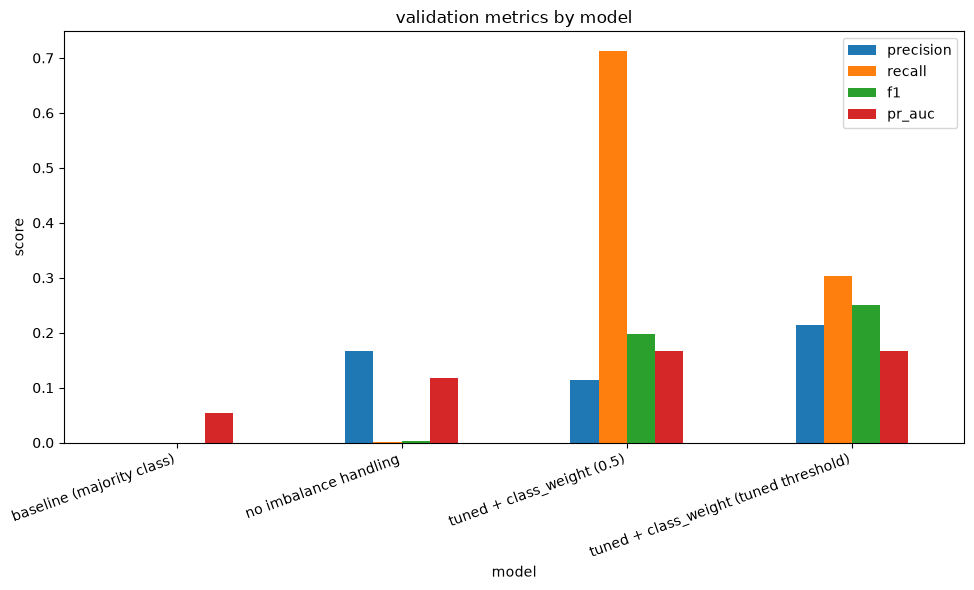

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
comparison[["precision", "recall", "f1", "pr_auc"]].plot(kind="bar", ax=ax)
ax.set_title("validation metrics by model")
ax.set_ylabel("score")
plt.xticks(rotation=20, ha="right")
fig.tight_layout()
fig.savefig(CHARTS_DIR / "06_model_comparison.png")
plt.show()

## feature importance (permutation, on validation)

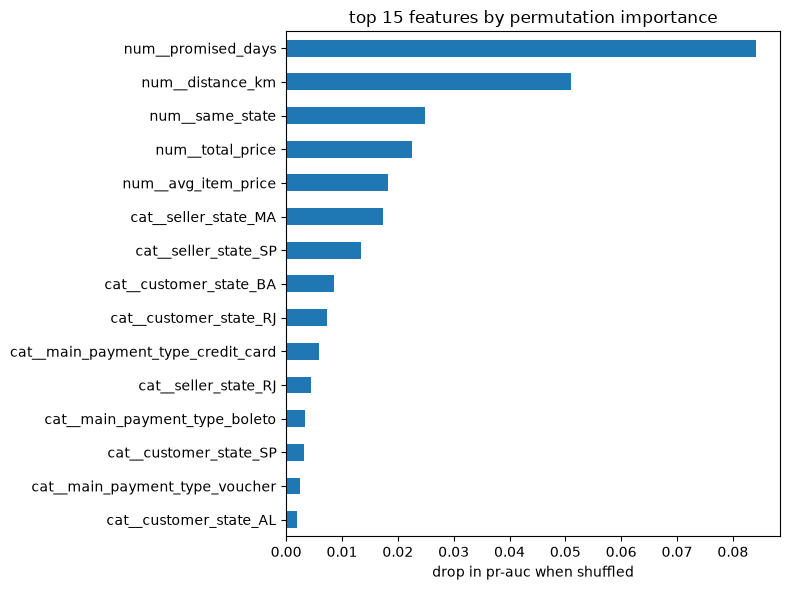

In [12]:
perm = permutation_importance(
    best_model, X_val, y_val, scoring="average_precision",
    n_repeats=5, random_state=42, n_jobs=-1,
)
importances = pd.Series(perm.importances_mean, index=feature_list).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
importances.sort_values().plot(kind="barh", ax=ax)
ax.set_xlabel("drop in pr-auc when shuffled")
ax.set_title("top 15 features by permutation importance")
fig.tight_layout()
fig.savefig(CHARTS_DIR / "06_feature_importance.png")
plt.show()

## touch the test set once, at the very end

In [13]:
final_test_default = evaluate(best_model, X_test, y_test, threshold=0.5)
final_test_tuned = evaluate(best_model, X_test, y_test, threshold=best_threshold)

print("test metrics, threshold 0.5:", final_test_default)
print("test metrics, tuned threshold:", final_test_tuned)

test metrics, threshold 0.5: {'accuracy': 0.4773355444997236, 'precision': 0.09786975045648205, 'recall': 0.8401253918495298, 'f1': 0.17531617967727867, 'roc_auc': 0.668795189060029, 'pr_auc': 0.11573340703987126}
test metrics, tuned threshold: {'accuracy': 0.8166804864566058, 'precision': 0.09772296015180265, 'recall': 0.21525600835945663, 'f1': 0.13442088091353996, 'roc_auc': 0.668795189060029, 'pr_auc': 0.11573340703987126}


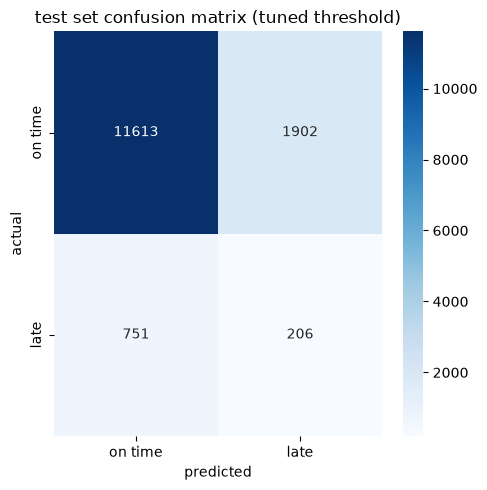

In [14]:
proba_test = best_model.predict_proba(X_test)[:, 1]
preds_test = (proba_test >= best_threshold).astype(int)

cm = confusion_matrix(y_test, preds_test)

fig, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["on time", "late"], yticklabels=["on time", "late"], ax=ax)
ax.set_xlabel("predicted")
ax.set_ylabel("actual")
ax.set_title("test set confusion matrix (tuned threshold)")
fig.tight_layout()
fig.savefig(CHARTS_DIR / "06_confusion_matrix.png")
plt.show()

## save the artifacts

In [15]:
joblib.dump(best_model, ARTIFACTS_DIR / "06_model.joblib")

leaderboard = search_df[["model_type", "params", "recall", "precision", "f1", "roc_auc", "pr_auc"]].head(10)

results_summary = f"""# Notebook 6 results

## validation comparison
{comparison.to_string()}

best model type: {best_model_type}
best hyperparameters: {best_params}
best threshold (max f1 on val): {best_threshold}

the model was picked purely on validation pr-auc (the metric this notebook set out to
optimise for a rare positive class), and the threshold was tuned on validation too. the
test set below is touched exactly once, after all of those choices were already locked in,
so it stays an unbiased estimate of how this does on unseen future orders.

## top 10 configs from the search (across all model types, by val pr-auc)
{leaderboard.to_string()}

## final test results (touched once)
threshold 0.5: {final_test_default}
tuned threshold ({best_threshold}): {final_test_tuned}

confusion matrix (test, tuned threshold, rows=actual, cols=predicted):
{cm}

## top 15 features by permutation importance
{importances.sort_values(ascending=False).to_string()}
"""

with open(ARTIFACTS_DIR / "06_results.md", "w") as f:
    f.write(results_summary)

print(results_summary)

# Notebook 6 results

## validation comparison
                                        accuracy  precision    recall        f1   roc_auc    pr_auc
model                                                                                              
baseline (majority class)               0.946583   0.000000  0.000000  0.000000  0.500000  0.053417
no imbalance handling                   0.946306   0.166667  0.001294  0.002567  0.705998  0.117959
tuned + class_weight (0.5)              0.689310   0.114197  0.712807  0.196856  0.773962  0.166771
tuned + class_weight (tuned threshold)  0.903669   0.214876  0.302717  0.251343  0.773962  0.166771

best model type: logistic_regression
best hyperparameters: {'max_iter': 1000, 'C': 10}
best threshold (max f1 on val): 0.71

the model was picked purely on validation pr-auc (the metric this notebook set out to
optimise for a rare positive class), and the threshold was tuned on validation too. the
test set below is touched exactly once, after all of 